In [1]:
  import pandas as pd
  import numpy as np
  import matplotlib.pyplot as plt
  import seaborn as sns

  print("Notebook is working")

Notebook is working


## Data Loading
Define the path to the raw Kaggle F1 dataset and load every CSV file into a dictionary of DataFrames, keyed by filename. Null values in this dataset are represented as `\N` rather than a blank, so we tell pandas to treat that string as missing data during import.

In [ ]:
import os
import pandas as pd

DATA_PATH = "../data/new folder"
files = os.listdir(DATA_PATH)
files

['circuits.csv',
 'constructors.csv',
 'constructor_results.csv',
 'constructor_standings.csv',
 'drivers.csv',
 'driver_standings.csv',
 'lap_times.csv',
 'pit_stops.csv',
 'qualifying.csv',
 'races.csv',
 'results.csv',
 'seasons.csv',
 'sprint_results.csv',
 'status.csv']

In [5]:
  tables = {}

  for file in files:
      if file.endswith(".csv"):
          name = file.replace(".csv", "")
          tables[name] = pd.read_csv(
              os.path.join(DATA_PATH, file),
              na_values=r"\N"
          )

In [6]:
  len(tables), tables.keys()

(14,
 dict_keys(['circuits', 'constructors', 'constructor_results', 'constructor_standings', 'drivers', 'driver_standings', 'lap_times', 'pit_stops', 'qualifying', 'races', 'results', 'seasons', 'sprint_results', 'status']))

In [7]:
  tables["races"]
  tables["results"]
  tables["drivers"]

,driverId,driverRef,number,code,forename,surname,dob,nationality,url
0,1,hamilton,44.0,HAM,Lewis,Hamilton,1985-01-07,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
1,2,heidfeld,NaN,HEI,Nick,Heidfeld,1977-05-10,German,http://en.wikipedia.org/wiki/Nick_Heidfeld
2,3,rosberg,6.0,ROS,Nico,Rosberg,1985-06-27,German,http://en.wikipedia.org/wiki/Nico_Rosberg
3,4,alonso,14.0,ALO,Fernando,Alonso,1981-07-29,Spanish,http://en.wikipedia.org/wiki/Fernando_Alonso
4,5,kovalainen,NaN,KOV,Heikki,Kovalainen,1981-10-19,Finnish,http://en.wikipedia.org/wiki/Heikki_Kovalainen
...,...,...,...,...,...,...,...,...,...
856,858,sargeant,2.0,SAR,Logan,Sargeant,2000-12-31,American,http://en.wikipedia.org/wiki/Logan_Sargeant
857,859,lawson,30.0,LAW,Liam,Lawson,2002-02-11,New Zealander,http://en.wikipedia.org/wiki/Liam_Lawson
858,860,bearman,38.0,BEA,Oliver,Bearman,2005-05-08,British,http://en.wikipedia.org/wiki/Oliver_Bearman
859,861,colapinto,43.0,COL,Franco,Colapinto,2003-05-27,Argentinian,http://en.wikipedia.org/wiki/Franco_Colapinto


## Initial Inspection — All Tables
Before doing any cleaning or transformation, inspect every loaded table's shape, columns, data types, and missing-value counts. This is observation only — nothing is modified yet — so we understand the data before making any decisions about it.


In [8]:
  for name, df in tables.items():
      print("=" * 60)
      print(name)
      print("Shape:", df.shape)
      print("\nColumns:")
      print(df.columns.tolist())
      print("\nData types:")
      print(df.dtypes)
      print("\nMissing values:")
      print(df.isna().sum())

circuits
Shape: (77, 9)

Columns:
['circuitId', 'circuitRef', 'name', 'location', 'country', 'lat', 'lng', 'alt', 'url']

Data types:
circuitId       int64
circuitRef        str
name              str
location          str
country           str
lat           float64
lng           float64
alt             int64
url               str
dtype: object

Missing values:
circuitId     0
circuitRef    0
name          0
location      0
country       0
lat           0
lng           0
alt           0
url           0
dtype: int64
constructors
Shape: (212, 5)

Columns:
['constructorId', 'constructorRef', 'name', 'nationality', 'url']

Data types:
constructorId     int64
constructorRef      str
name                str
nationality         str
url                 str
dtype: object

Missing values:
constructorId     0
constructorRef    0
name              0
nationality       0
url               0
dtype: int64
constructor_results
Shape: (12625, 5)

Columns:
['constructorResultsId', 'raceId', 'constructorId'

## Inspecting Key Tables Individually
Take a closer look at the tables central to this analysis — races, results, drivers, constructors, circuits, qualifying, and status — using `.head()`, `.info()`, and `.describe()` to catch details a summary loop might miss.

In [9]:
races = tables["races"]
races.head()
races.info()
races.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 1125 entries, 0 to 1124
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   raceId       1125 non-null   int64
 1   year         1125 non-null   int64
 2   round        1125 non-null   int64
 3   circuitId    1125 non-null   int64
 4   name         1125 non-null   str  
 5   date         1125 non-null   str  
 6   time         394 non-null    str  
 7   url          1125 non-null   str  
 8   fp1_date     90 non-null     str  
 9   fp1_time     68 non-null     str  
 10  fp2_date     90 non-null     str  
 11  fp2_time     68 non-null     str  
 12  fp3_date     72 non-null     str  
 13  fp3_time     53 non-null     str  
 14  quali_date   90 non-null     str  
 15  quali_time   68 non-null     str  
 16  sprint_date  18 non-null     str  
 17  sprint_time  15 non-null     str  
dtypes: int64(4), str(14)
memory usage: 158.3 KB


,raceId,year,round,circuitId,name,date,time,url,fp1_date,fp1_time,fp2_date,fp2_time,fp3_date,fp3_time,quali_date,quali_time,sprint_date,sprint_time
count,1125.000000,1125.000000,1125.000000,1125.000000,1125,1125,394,1125,90,68,90,68,72,53,90,68,18,15
unique,NaN,NaN,NaN,NaN,54,1125,34,1125,90,20,90,19,72,18,90,15,18,12
top,NaN,NaN,NaN,NaN,British Grand Prix,2009-03-29,12:00:00,http://en.wikipedia.org/wiki/2009_Australian_G...,2021-04-16,11:30:00,2021-04-16,15:00:00,2021-04-17,10:30:00,2021-04-17,14:00:00,2021-07-17,14:30:00
freq,NaN,NaN,NaN,NaN,75,1,113,1,1,18,1,22,1,14,1,24,1,4
mean,565.710222,1992.703111,8.579556,23.889778,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,328.813817,20.603848,5.159910,19.633527,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,1950.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,282.000000,1977.000000,4.000000,9.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,563.000000,1994.000000,8.000000,18.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,845.000000,2011.000000,13.000000,34.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
results = tables["results"]
results.head()
results.info()
results.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 26759 entries, 0 to 26758
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   resultId         26759 non-null  int64  
 1   raceId           26759 non-null  int64  
 2   driverId         26759 non-null  int64  
 3   constructorId    26759 non-null  int64  
 4   number           26753 non-null  float64
 5   grid             26759 non-null  int64  
 6   position         15806 non-null  float64
 7   positionText     26759 non-null  str    
 8   positionOrder    26759 non-null  int64  
 9   points           26759 non-null  float64
 10  laps             26759 non-null  int64  
 11  time             7680 non-null   str    
 12  milliseconds     7680 non-null   float64
 13  fastestLap       8252 non-null   float64
 14  rank             8510 non-null   float64
 15  fastestLapTime   8252 non-null   str    
 16  fastestLapSpeed  8252 non-null   float64
 17  statusId         26759 

,resultId,raceId,driverId,constructorId,number,grid,position,positionText,positionOrder,points,laps,time,milliseconds,fastestLap,rank,fastestLapTime,fastestLapSpeed,statusId
count,26759.000000,26759.000000,26759.000000,26759.000000,26753.000000,26759.000000,15806.000000,26759,26759.000000,26759.000000,26759.000000,7680,7.680000e+03,8252.000000,8510.000000,8252,8252.000000,26759.000000
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,39,NaN,NaN,NaN,7410,NaN,NaN,NaN,7473,NaN,NaN
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,R,NaN,NaN,NaN,+8:22.19,NaN,NaN,NaN,1:14.117,NaN,NaN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,8897,NaN,NaN,NaN,5,NaN,NaN,NaN,4,NaN,NaN
mean,13380.977391,551.687283,278.673530,50.180537,18.153927,11.134796,8.020499,NaN,12.794051,1.987632,46.301768,NaN,6.185833e+06,42.732913,10.334313,NaN,204.116330,17.224971
std,7726.134642,313.265036,282.703039,61.551498,15.581135,7.202860,4.840796,NaN,7.665951,4.351209,29.496557,NaN,1.669306e+06,16.603460,6.140957,NaN,21.377265,26.026104
min,1.000000,1.000000,1.000000,1.000000,0.000000,0.000000,1.000000,NaN,1.000000,0.000000,0.000000,NaN,5.260000e+02,1.000000,0.000000,NaN,89.540000,1.000000
25%,6690.500000,300.000000,57.000000,6.000000,7.000000,5.000000,4.000000,NaN,6.000000,0.000000,23.000000,NaN,5.378454e+06,33.000000,5.000000,NaN,193.322500,1.000000
50%,13380.000000,531.000000,172.000000,25.000000,16.000000,11.000000,8.000000,NaN,12.000000,0.000000,53.000000,NaN,5.788194e+06,46.000000,10.000000,NaN,204.894000,10.000000
75%,20069.500000,811.000000,399.500000,63.000000,24.000000,17.000000,11.000000,NaN,18.000000,2.000000,66.000000,NaN,6.402676e+06,54.000000,15.000000,NaN,217.324000,14.000000


In [11]:
drivers = tables["drivers"]
drivers.head()
drivers.info()
drivers.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 861 entries, 0 to 860
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   driverId     861 non-null    int64  
 1   driverRef    861 non-null    str    
 2   number       59 non-null     float64
 3   code         104 non-null    str    
 4   forename     861 non-null    str    
 5   surname      861 non-null    str    
 6   dob          861 non-null    str    
 7   nationality  861 non-null    str    
 8   url          861 non-null    str    
dtypes: float64(1), int64(1), str(7)
memory usage: 60.7 KB


,driverId,driverRef,number,code,forename,surname,dob,nationality,url
count,861.000000,861,59.000000,104,861,861,861,861,861
unique,NaN,861,NaN,97,478,802,843,43,861
top,NaN,hamilton,NaN,ALB,John,Taylor,1950-01-18,British,http://en.wikipedia.org/wiki/Lewis_Hamilton
freq,NaN,1,NaN,2,14,5,2,166,1
mean,431.061556,NaN,33.966102,NaN,NaN,NaN,NaN,NaN,NaN
std,248.793797,NaN,28.638632,NaN,NaN,NaN,NaN,NaN,NaN
min,1.000000,NaN,2.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,216.000000,NaN,11.500000,NaN,NaN,NaN,NaN,NaN,NaN
50%,431.000000,NaN,25.000000,NaN,NaN,NaN,NaN,NaN,NaN
75%,646.000000,NaN,46.000000,NaN,NaN,NaN,NaN,NaN,NaN


In [12]:
constructors = tables["constructors"]
constructors.head()
constructors.info()
constructors.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 212 entries, 0 to 211
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   constructorId   212 non-null    int64
 1   constructorRef  212 non-null    str  
 2   name            212 non-null    str  
 3   nationality     212 non-null    str  
 4   url             212 non-null    str  
dtypes: int64(1), str(4)
memory usage: 8.4 KB


,constructorId,constructorRef,name,nationality,url
count,212.000000,212,212,212,212
unique,NaN,212,212,24,175
top,NaN,mclaren,McLaren,British,http://en.wikipedia.org/wiki/Cooper_Car_Company
freq,NaN,1,1,86,11
mean,107.547170,NaN,NaN,NaN,NaN
std,61.952685,NaN,NaN,NaN,NaN
min,1.000000,NaN,NaN,NaN,NaN
25%,54.750000,NaN,NaN,NaN,NaN
50%,107.500000,NaN,NaN,NaN,NaN
75%,160.250000,NaN,NaN,NaN,NaN


In [13]:
circuits = tables["circuits"]
circuits.head()
circuits.info()
circuits.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 77 entries, 0 to 76
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   circuitId   77 non-null     int64  
 1   circuitRef  77 non-null     str    
 2   name        77 non-null     str    
 3   location    77 non-null     str    
 4   country     77 non-null     str    
 5   lat         77 non-null     float64
 6   lng         77 non-null     float64
 7   alt         77 non-null     int64  
 8   url         77 non-null     str    
dtypes: float64(2), int64(2), str(5)
memory usage: 5.5 KB


,circuitId,circuitRef,name,location,country,lat,lng,alt,url
count,77.000000,77,77,77,77,77.000000,77.000000,77.000000,77
unique,NaN,77,77,75,35,NaN,NaN,NaN,77
top,NaN,albert_park,Albert Park Grand Prix Circuit,California,USA,NaN,NaN,NaN,http://en.wikipedia.org/wiki/Melbourne_Grand_P...
freq,NaN,1,1,2,11,NaN,NaN,NaN,1
mean,39.883117,NaN,NaN,NaN,NaN,33.442925,1.076683,247.012987,NaN
std,23.001701,NaN,NaN,NaN,NaN,22.808866,65.516951,362.738469,NaN
min,1.000000,NaN,NaN,NaN,NaN,-37.849700,-118.189000,-7.000000,NaN
25%,20.000000,NaN,NaN,NaN,NaN,32.777400,-9.394170,18.000000,NaN
50%,40.000000,NaN,NaN,NaN,NaN,40.951700,3.930830,129.000000,NaN
75%,59.000000,NaN,NaN,NaN,NaN,46.958900,19.248600,332.000000,NaN


In [14]:
qualifying = tables["qualifying"]
qualifying.head()
qualifying.info()
qualifying.describe(include="all")

<class 'pandas.DataFrame'>
RangeIndex: 10494 entries, 0 to 10493
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   qualifyId      10494 non-null  int64
 1   raceId         10494 non-null  int64
 2   driverId       10494 non-null  int64
 3   constructorId  10494 non-null  int64
 4   number         10494 non-null  int64
 5   position       10494 non-null  int64
 6   q1             10338 non-null  str  
 7   q2             5847 non-null   str  
 8   q3             3629 non-null   str  
dtypes: int64(6), str(3)
memory usage: 738.0 KB


,qualifyId,raceId,driverId,constructorId,number,position,q1,q2,q3
count,10494.000000,10494.000000,10494.000000,10494.000000,10494.000000,10494.000000,10338,5847,3629
unique,NaN,NaN,NaN,NaN,NaN,NaN,9146,5473,3470
top,NaN,NaN,NaN,NaN,NaN,NaN,1:20.888,1:27.219,1:31.478
freq,NaN,NaN,NaN,NaN,NaN,NaN,4,3,3
mean,5262.482847,624.600915,343.002287,47.918430,18.786449,11.195826,NaN,NaN,NaN
std,3046.588486,428.298147,389.586448,73.217993,18.447502,6.260374,NaN,NaN,NaN
min,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,NaN,NaN,NaN
25%,2625.250000,160.000000,17.000000,4.000000,7.000000,6.000000,NaN,NaN,NaN
50%,5249.500000,870.000000,60.000000,9.000000,14.000000,11.000000,NaN,NaN,NaN
75%,7893.750000,1006.000000,822.000000,31.000000,22.000000,16.000000,NaN,NaN,NaN


In [15]:
status = tables["status"]
status.head()
status.info()

<class 'pandas.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   statusId  139 non-null    int64
 1   status    139 non-null    str  
dtypes: int64(1), str(1)
memory usage: 2.3 KB


## Validating Relationships Between Tables
Check that the ID columns linking tables together (race, driver, constructor, circuit) are consistent across the tables that reference them. This confirms the dataset's relational structure is intact before we merge anything.

In [16]:
print("Results race IDs:", results["raceId"].nunique())
print("Races race IDs:", races["raceId"].nunique())

Results race IDs: 1125
Races race IDs: 1125


In [17]:
print("Results driver IDs:", results["driverId"].nunique())
print("Drivers driver IDs:", drivers["driverId"].nunique())

Results driver IDs: 861
Drivers driver IDs: 861


In [18]:
print("Results constructor IDs:", results["constructorId"].nunique())
print("Constructors constructor IDs:", constructors["constructorId"].nunique())

Results constructor IDs: 211
Constructors constructor IDs: 212


In [19]:
print("Races circuit IDs:", races["circuitId"].nunique())
print("Circuits circuit IDs:", circuits["circuitId"].nunique())

Races circuit IDs: 77
Circuits circuit IDs: 77


## Building the Master Dataset
Starting from `results` (one row per driver per race), progressively merge in descriptive context from `races`, `drivers`, `constructors`, and `status`, using left joins to ensure no result rows are lost in the process.


In [20]:
master = results.copy()

In [21]:
master = master.merge(
    races[["raceId", "year", "round", "circuitId", "name"]],
    on="raceId",
    how="left",
    suffixes=("", "_race")
)

In [22]:
master = master.merge(
    drivers[["driverId", "driverRef", "forename", "surname", "nationality"]],
    on="driverId",
    how="left"
)

In [23]:
master = master.merge(
    constructors[["constructorId", "constructorRef", "name", "nationality"]],
    on="constructorId",
    how="left",
    suffixes=("", "_constructor")
)

In [24]:
master = master.merge(
    status[["statusId", "status"]],
    on="statusId",
    how="left"
)

## Validating the Merge
Confirm the merged dataset's row count matches the original `results` table (ruling out accidental row duplication), and check for unmatched rows that would indicate a join went wrong.

In [25]:
print("Results rows:", len(results))
print("Master rows:", len(master))

Results rows: 26759
Master rows: 26759


In [26]:
master["forename"].isna().sum()

np.int64(0)

In [27]:
master["name_constructor"].isna().sum()

np.int64(0)

In [28]:
master.head()
master.columns.tolist()

['resultId',
 'raceId',
 'driverId',
 'constructorId',
 'number',
 'grid',
 'position',
 'positionText',
 'positionOrder',
 'points',
 'laps',
 'time',
 'milliseconds',
 'fastestLap',
 'rank',
 'fastestLapTime',
 'fastestLapSpeed',
 'statusId',
 'year',
 'round',
 'circuitId',
 'name',
 'driverRef',
 'forename',
 'surname',
 'nationality',
 'constructorRef',
 'name_constructor',
 'nationality_constructor',
 'status']

## Cleaning: Finish Position
Convert the raw `position` column to a proper numeric `finish_position`, coercing non-numeric entries (like retirement codes) to NaN. Cross-reference the `status` column to understand *why* certain rows have no numeric finish, rather than assuming they're all simple DNFs.

In [29]:
master["finish_position"] = pd.to_numeric(
    master["position"],
    errors="coerce"
)

In [30]:
master["finish_position"].isna().sum()

np.int64(10953)

In [31]:
master["status"].value_counts().head(30)

status
Finished              7674
+1 Lap                4037
Engine                2026
+2 Laps               1613
Accident              1062
Did not qualify       1025
Collision              854
Gearbox                810
Spun off               795
+3 Laps                731
Suspension             431
+4 Laps                405
Did not prequalify     331
Transmission           321
Electrical             316
Brakes                 254
Withdrew               248
+5 Laps                221
Clutch                 214
Not classified         172
Fuel system            155
+6 Laps                153
Disqualified           147
Turbo                  146
Hydraulics             139
Overheating            133
Ignition               128
Oil leak               124
Throttle               111
Retired                107
Name: count, dtype: int64

## Key Analytical Variable: Grid-to-Finish Change
Create `grid_to_finish`, the difference between starting grid position and finishing position, to measure how many places each driver gained or lost during a race.

In [32]:
master["grid_to_finish"] = (
    master["grid"] - master["finish_position"]
)

In [33]:
master[["grid", "finish_position", "grid_to_finish"]].head(20)

,grid,finish_position,grid_to_finish
0,1,1.0,0.0
1,5,2.0,3.0
2,7,3.0,4.0
3,11,4.0,7.0
4,3,5.0,-2.0
5,13,6.0,7.0
6,17,7.0,10.0
7,15,8.0,7.0
8,2,NaN,NaN
9,18,NaN,NaN


## Descriptive Analysis
Summarize overall finishing performance and points, then break down average finish position and average position change by constructor to identify top performers.


In [34]:
master["finish_position"].describe()

count    15806.000000
mean         8.020499
std          4.840796
min          1.000000
25%          4.000000
50%          8.000000
75%         11.000000
max         33.000000
Name: finish_position, dtype: float64

In [35]:
master["points"].describe()

count    26759.000000
mean         1.987632
std          4.351209
min          0.000000
25%          0.000000
50%          0.000000
75%          2.000000
max         50.000000
Name: points, dtype: float64

In [36]:
constructor_performance = (
    master
    .groupby("name_constructor")["finish_position"]
    .mean()
    .sort_values()
)
constructor_performance.head(10)

name_constructor
Matra-Ford       3.655172
Brabham-Repco    3.871795
Brawn            4.062500
Vanwall          4.185185
Lancia           4.333333
Deidt            4.333333
Eagle-Weslake    4.333333
Mercedes         4.379965
Lotus-Ford       4.610169
Cooper-BRM       4.625000
Name: finish_position, dtype: float64

In [37]:
constructor_position_change = (
    master
    .groupby("name_constructor")["grid_to_finish"]
    .mean()
    .sort_values(ascending=False)
)
constructor_position_change.head(10)

name_constructor
Schroeder    20.500000
BMW          15.333333
Langley      15.000000
Stebro       14.000000
AFM          14.000000
RAM          12.714286
Sherman      12.500000
Coloni       12.250000
Pacific      11.833333
Trevis       11.750000
Name: grid_to_finish, dtype: float64

## Performance Over Time
Aggregate average finish position, average grid-to-finish change, and total points by season to see how overall performance metrics have trended across F1's history.

In [38]:
yearly_performance = (
    master
    .groupby("year")
    .agg(
        avg_finish=("finish_position", "mean"),
        avg_grid_change=("grid_to_finish", "mean"),
        total_points=("points", "sum")
    )
    .reset_index()
)

In [39]:
yearly_performance.head()
yearly_performance.tail()

,year,avg_finish,avg_grid_change,total_points
70,2020,9.066202,0.937282,1734.0
71,2021,9.409794,0.458763,2189.5
72,2022,9.119681,0.893617,2242.0
73,2023,9.341969,0.274611,2242.0
74,2024,9.547564,0.180974,2443.0


## Competitive Balance
Calculate each constructor's share of total points within each season, as a basis for measuring how concentrated or evenly distributed competitive success has been across different eras.

In [40]:
constructor_year_points = (
    master
    .groupby(["year", "name_constructor"])["points"]
    .sum()
    .reset_index()
)

In [41]:
constructor_year_points["points_share"] = (
    constructor_year_points["points"]
    /
    constructor_year_points
    .groupby("year")["points"]
    .transform("sum")
)

In [42]:
constructor_year_points.head()

,year,name_constructor,points,points_share
0,1950,Adams,0.0,0.000000
1,1950,Alfa Romeo,89.0,0.529762
2,1950,Alta,0.0,0.000000
3,1950,Cooper,0.0,0.000000
4,1950,Deidt,10.0,0.059524


## Grid Position Analysis
Group results by starting grid position to see the average finishing position, average position change, and race count associated with each starting slot — directly addressing how much starting position influences race-day outcome.

In [43]:
grid_finish = (
    master
    .groupby("grid")
    .agg(
        avg_finish=("finish_position", "mean"),
        avg_position_change=("grid_to_finish", "mean"),
        races=("raceId", "count")
    )
    .reset_index()
)

In [44]:
grid_finish.head(20)

,grid,avg_finish,avg_position_change,races
0,0,13.616667,-13.616667,1638
1,1,2.362385,-1.362385,1136
2,2,3.207503,-1.207503,1125
3,3,3.739130,-0.739130,1130
4,4,4.457143,-0.457143,1132
5,5,5.102731,-0.102731,1132
6,6,5.705805,0.294195,1125
7,7,6.426702,0.573298,1135
8,8,7.057487,0.942513,1129
9,9,7.233957,1.766043,1132


In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

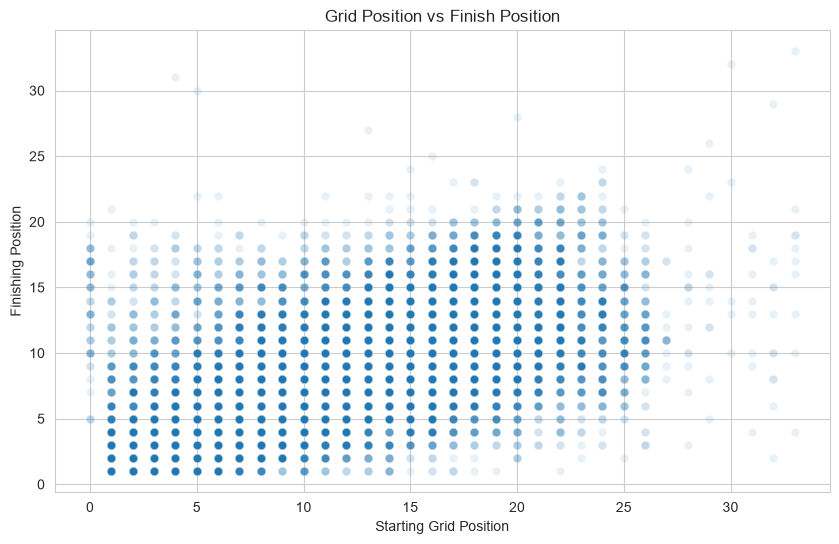

In [46]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=master, x="grid", y="finish_position", alpha=0.1)
plt.title("Grid Position vs Finish Position")
plt.xlabel("Starting Grid Position")
plt.ylabel("Finishing Position")
plt.show()

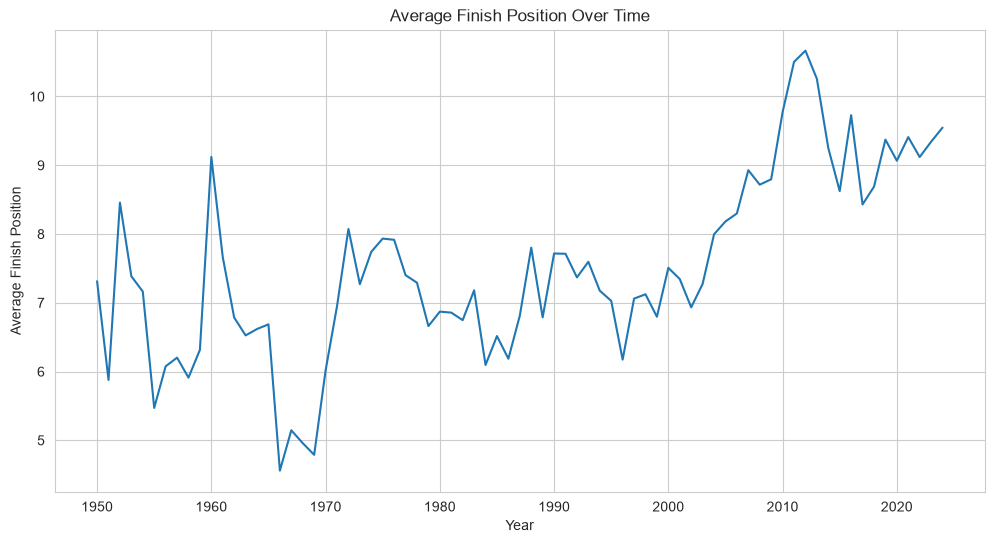

In [47]:
plt.figure(figsize=(12, 6))
plt.plot(yearly_performance["year"], yearly_performance["avg_finish"])
plt.title("Average Finish Position Over Time")
plt.xlabel("Year")
plt.ylabel("Average Finish Position")
plt.show()

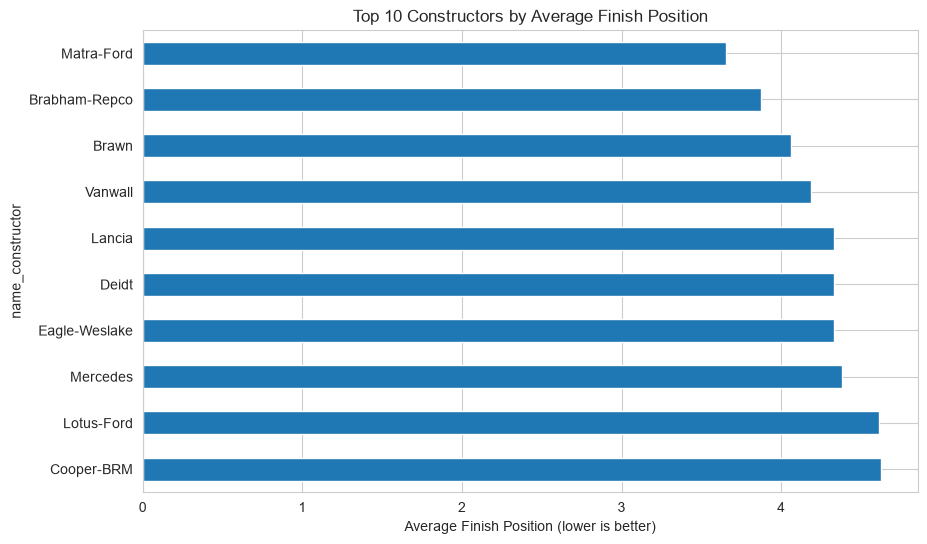

In [48]:
plt.figure(figsize=(10, 6))
constructor_performance.head(10).plot(kind="barh")
plt.title("Top 10 Constructors by Average Finish Position")
plt.xlabel("Average Finish Position (lower is better)")
plt.gca().invert_yaxis()
plt.show()

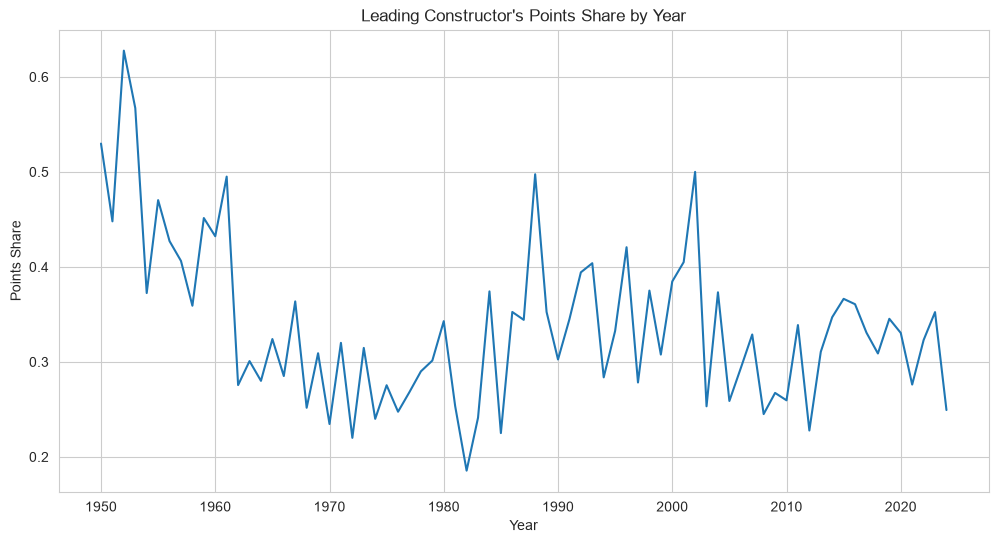

In [49]:
top_share_by_year = (
    constructor_year_points
    .sort_values(["year", "points_share"], ascending=[True, False])
    .groupby("year")
    .first()["points_share"]
)

plt.figure(figsize=(12, 6))
plt.plot(top_share_by_year.index, top_share_by_year.values)
plt.title("Leading Constructor's Points Share by Year")
plt.xlabel("Year")
plt.ylabel("Points Share")
plt.show()

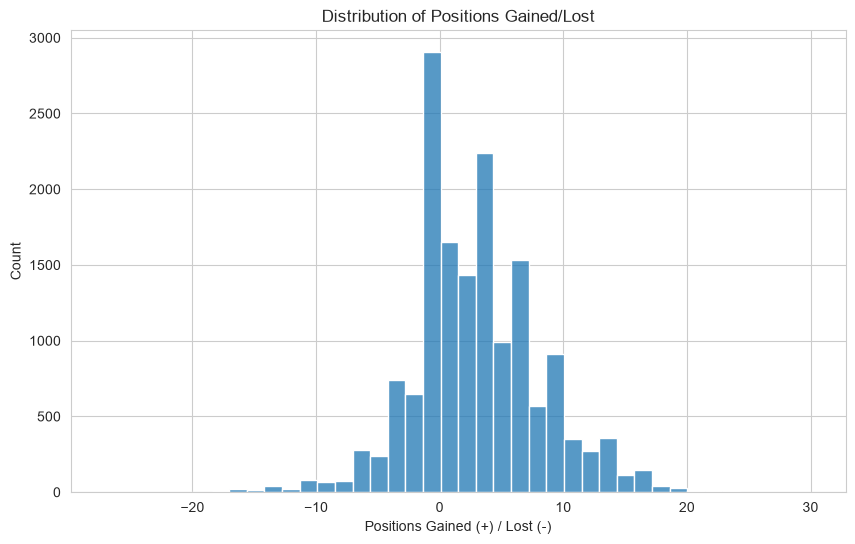

In [50]:
plt.figure(figsize=(10, 6))
sns.histplot(master["grid_to_finish"].dropna(), bins=40)
plt.title("Distribution of Positions Gained/Lost")
plt.xlabel("Positions Gained (+) / Lost (-)")
plt.show()

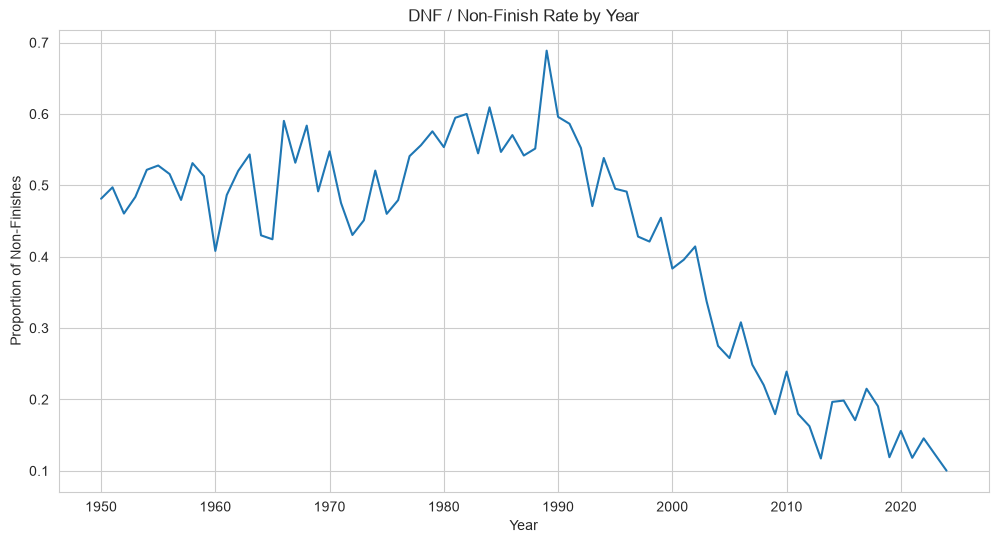

In [51]:
master["is_dnf"] = master["finish_position"].isna()

dnf_rate_by_year = master.groupby("year")["is_dnf"].mean()

plt.figure(figsize=(12, 6))
plt.plot(dnf_rate_by_year.index, dnf_rate_by_year.values)
plt.title("DNF / Non-Finish Rate by Year")
plt.xlabel("Year")
plt.ylabel("Proportion of Non-Finishes")
plt.show()

In [52]:
master[["finish_position", "points", "grid_to_finish"]].describe()

,finish_position,points,grid_to_finish
count,15806.000000,26759.000000,15806.000000
mean,8.020499,1.987632,2.956029
std,4.840796,4.351209,5.193920
min,1.000000,0.000000,-27.000000
25%,4.000000,0.000000,0.000000
50%,8.000000,0.000000,2.000000
75%,11.000000,2.000000,6.000000
max,33.000000,50.000000,30.000000


In [53]:
master["finish_position"].isna().mean()

np.float64(0.4093202287080982)

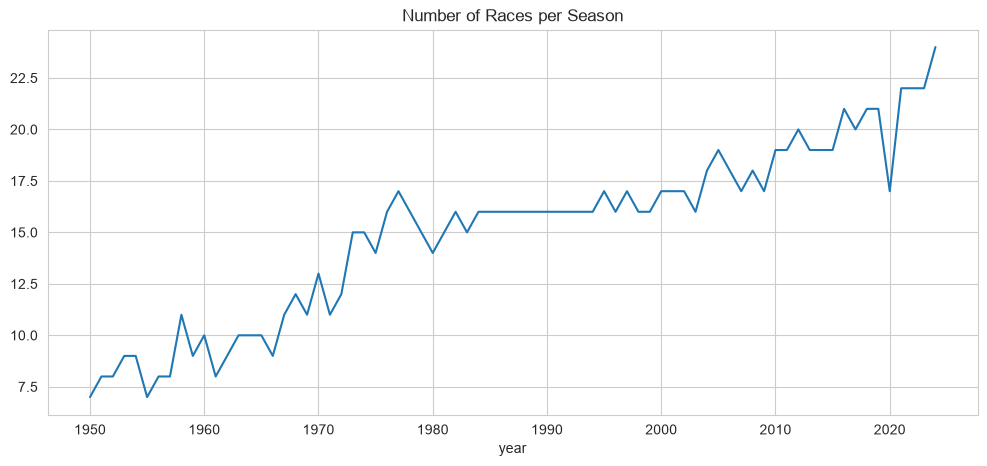

In [54]:
races_per_year = races.groupby("year")["raceId"].nunique()
races_per_year.plot(figsize=(12, 5), title="Number of Races per Season")
plt.show()

In [55]:
constructors[["constructorRef", "name"]].sort_values("name")

,constructorRef,name
145,afm,AFM
38,ags,AGS
52,ats,ATS
159,adams,Adams
49,alfa,Alfa Romeo
...,...,...
105,watson,Watson
158,wetteroth,Wetteroth
2,williams,Williams
57,wolf,Wolf


In [56]:
master[master["is_dnf"]]["status"].value_counts().head(15)

status
Engine                1886
Did not qualify       1025
Accident               987
Collision              806
Gearbox                774
Spun off               754
Suspension             407
Did not prequalify     331
Transmission           310
Electrical             298
Withdrew               245
Brakes                 235
Clutch                 201
Not classified         171
Disqualified           147
Name: count, dtype: int64

 Findings

* Competitive balance: Average finishing position fluctuated over time, while recent seasons remained relatively stable around 9th place. The leading constructor's points share also varied across seasons, showing that team dominance changed between eras.

* Constructor dominance: Matra-Ford had the best average finishing position among the top 10 constructors at 3.66. However, historical averages should be interpreted cautiously because F1 regulations, scoring systems, and competition changed across eras.

* Grid → finish relationship: Starting position has a clear relationship with finishing position. Drivers starting near the front generally finished higher; for example, Grid 1 had an average finishing position of 2.36, compared with 7.92 from Grid 10.

* Position gains/losses: Most drivers finished relatively close to their starting positions, although some gained or lost several places during races.

* Non-finish trends: Non-finish rates were generally higher and more variable in earlier decades, while later seasons showed a noticeable decline.
 
 Key Finding

Overall, the analysis shows that *starting position is strongly associated with race finishing position*, while constructor strength, race-day position changes, and reliability also contribute to F1 performance.


In [57]:
master.to_csv(
    "../output/f1_master_clean.csv",
    index=False
)

import os
print(os.path.exists("../output/f1_master_clean.csv"))

True
